In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!mkdir -p /content/drive/MyDrive/Traffic_Signs
!kaggle datasets download -d valentynsichkar/traffic-signs-preprocessed -p /content/drive/MyDrive/Traffic_Signs
!unzip -o /content/drive/MyDrive/Traffic_Signs/traffic-signs-preprocessed.zip -d /content/drive/MyDrive/Traffic_Signs/


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
Archive:  /content/drive/MyDrive/Traffic_Signs/traffic-signs-preprocessed.zip
  inflating: /content/drive/MyDrive/Traffic_Signs/data0.pickle  
  inflating: /content/drive/MyDrive/Traffic_Signs/data1.pickle  
  inflating: /content/drive/MyDrive/Traffic_Signs/data2.pickle  
  inflating: /co

In [ ]:
import pickle
import numpy as np

data_path = "/content/drive/MyDrive/Traffic_Signs/"

with open(data_path + "train.pickle", mode='rb') as f:
    train_data = pickle.load(f)

with open(data_path + "valid.pickle", mode='rb') as f:
    valid_data = pickle.load(f)

with open(data_path + "test.pickle", mode='rb') as f:
    test_data = pickle.load(f)


In [ ]:
print(train_data.keys())



dict_keys(['coords', 'labels', 'features', 'sizes'])


In [ ]:
from sklearn.model_selection import train_test_split

X_train = np.concatenate([train_data["features"], valid_data["features"]])
y_train = np.concatenate([train_data["labels"], valid_data["labels"]])
X_test = test_data["features"]
y_test = test_data["labels"]

In [ ]:
import pandas as pd

label_names_df = pd.read_csv(data_path+"label_names.csv")
label_dict = dict(zip(label_names_df["ClassId"], label_names_df["SignName"]))

In [ ]:
from collections import Counter

class_counts = Counter(y_train)
max_samples = max(class_counts.values())

In [ ]:
X_train_notaugumented, X_val_notaugumented, y_train_notaugumented, y_val_notaugumented = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [ ]:
from collections import Counter
import numpy as np
import random

def balance_dataset(X, y, augment_func):

    unique, counts = np.unique(y, return_counts=True)
    max_count = np.max(counts)

    X_list = []
    y_list = []

    for label in np.unique(y):
        indices = np.where(y == label)[0]
        X_class = X[indices]
        count = X_class.shape[0]

        X_list.append(X_class)
        y_list.append(np.full((count,), label))

        samples_needed = max_count - count

        for _ in range(samples_needed):
            rnd_idx = random.randint(0, count - 1)
            augmented_img = augment_func(X_class[rnd_idx])
            X_list.append(np.expand_dims(augmented_img, axis=0))
            y_list.append(np.array([label]))

    X_balanced = np.concatenate(X_list, axis=0)
    y_balanced = np.concatenate(y_list, axis=0)

    return X_balanced, y_balanced


In [ ]:
import cv2
import random

def augment_image(image):
    operations = [
        lambda img: cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE) if random.random() > 0.5 else cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE),
        lambda img: rotate_random_angle(img),
        lambda img: cv2.GaussianBlur(img, (3, 3), 0) if random.random() > 0.5 else img,
        lambda img: change_brightness_contrast(img),
        lambda img: random_shift(img)
    ]
    return random.choice(operations)(image)

def rotate_random_angle(image):
    angle = random.uniform(-45, 45)
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))
    return rotated_image
def change_brightness_contrast(image):
    alpha = random.uniform(0.7, 1.3)
    beta = random.randint(-30, 30)
    adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return adjusted

def random_shift(image):
    height, width = image.shape[:2]
    max_shift = 10
    tx = random.randint(-max_shift, max_shift)
    ty = random.randint(-max_shift, max_shift)
    matrix = np.float32([[1, 0, tx], [0, 1, ty]])
    shifted_image = cv2.warpAffine(image, matrix, (width, height))
    return shifted_image



X_augmented, y_augmented = [], []
for label in range(len(label_dict)):
    class_images = X_train[y_train == label]
    count = class_counts[label] if label in class_counts else 0
    samples_needed = max_samples - count

    for _ in range(samples_needed):
        img = random.choice(class_images)
        X_augmented.append(augment_image(img))
        y_augmented.append(label)


X_train_final, y_train_final = balance_dataset(X_train_notaugumented, y_train_notaugumented, augment_image)

X_val_final, y_val_final = balance_dataset(X_val_notaugumented, y_val_notaugumented, augment_image)

In [ ]:
print("Nowy zbiór treningowy:")
print(f"Łączna liczba próbek: {len(y_train_final)}")
print(f"Liczba klas: {len(set(y_train_final))}")
print(f"Średnia liczba próbek na klasę: {np.mean(list(Counter(y_train_final).values()))}")
print(f"Minimalna liczba próbek w klasie: {min(Counter(y_train_final).values())}")
print(f"Maksymalna liczba próbek w klasie: {max(Counter(y_train_final).values())}")

print("\nNowy zbiór walidacyjny:")
print(f"Łączna liczba próbek: {len(y_val_final)}")
print(f"Liczba klas: {len(set(y_val_final))}")
print(f"Średnia liczba próbek na klasę: {np.mean(list(Counter(y_val_final).values()))}")
print(f"Minimalna liczba próbek w klasie: {min(Counter(y_val_final).values())}")
print(f"Maksymalna liczba próbek w klasie: {max(Counter(y_val_final).values())}")

print("\nZbiór testowy (bez zmian):")
print(f"Łączna liczba próbek: {len(y_test)}")
print(f"Liczba klas: {len(set(y_test))}")
print(f"Średnia liczba próbek na klasę: {np.mean(list(Counter(y_test).values()))}")
print(f"Minimalna liczba próbek w klasie: {min(Counter(y_test).values())}")
print(f"Maksymalna liczba próbek w klasie: {max(Counter(y_test).values())}")


Nowy zbiór treningowy:
Łączna liczba próbek: 77400
Liczba klas: 43
Średnia liczba próbek na klasę: 1800.0
Minimalna liczba próbek w klasie: 1800
Maksymalna liczba próbek w klasie: 1800

Nowy zbiór walidacyjny:
Łączna liczba próbek: 19350
Liczba klas: 43
Średnia liczba próbek na klasę: 450.0
Minimalna liczba próbek w klasie: 450
Maksymalna liczba próbek w klasie: 450

Zbiór testowy (bez zmian):
Łączna liczba próbek: 12630
Liczba klas: 43
Średnia liczba próbek na klasę: 293.72093023255815
Minimalna liczba próbek w klasie: 60
Maksymalna liczba próbek w klasie: 750


In [ ]:
balanced_train_data = {"features": X_train_final, "labels": y_train_final}
balanced_valid_data = {"features": X_val_final, "labels": y_val_final}
balanced_test_data = {"features": X_test, "labels": y_test}

with open(data_path + "train_balanced.pickle", "wb") as f:
    pickle.dump(balanced_train_data, f)

with open(data_path + "valid_balanced.pickle", "wb") as f:
    pickle.dump(balanced_valid_data, f)

with open(data_path + "test_balanced.pickle", "wb") as f:
    pickle.dump(balanced_test_data, f)


In [ ]:
print(f"Liczba próbek treningowych: {len(balanced_train_data['features'])}")
print(f"Liczba próbek walidacyjnych: {len(balanced_valid_data['features'])}")
print(f"Liczba próbek testowych: {len(test_data['features'])}")


Liczba próbek treningowych: 77400
Liczba próbek walidacyjnych: 19350
Liczba próbek testowych: 12630


In [ ]:
def analyze_class_distribution(y, title):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{title}:")
    print(f"Łączna liczba próbek: {len(y)}")
    print(f"Liczba klas: {len(unique)}")
    print(f"Średnia liczba próbek na klasę: {np.mean(counts):.1f}")
    print(f"Minimalna liczba próbek w klasie: {np.min(counts)}")
    print(f"Maksymalna liczba próbek w klasie: {np.max(counts)}")

    return unique, counts

    print("=== Oryginalne zbiory ===")
old_train, old_counts_train = analyze_class_distribution(train_data["labels"], "Zbiór treningowy")
old_val, old_counts_val = analyze_class_distribution(valid_data["labels"], "Zbiór walidacyjny")
_, _ = analyze_class_distribution(test_data["labels"], "Zbiór testowy")

print("\n=== Nowe zbiory ===")
unique_train, counts_train = analyze_class_distribution(balanced_train_data["labels"], "Nowy zbiór treningowy (80%)")
unique_val, counts_val = analyze_class_distribution(balanced_valid_data["labels"], "Nowy zbiór walidacyjny (20%)")
_, _ = analyze_class_distribution(balanced_test_data["labels"], "Zbiór testowy (bez zmian)")



Zbiór treningowy:
Łączna liczba próbek: 34799
Liczba klas: 43
Średnia liczba próbek na klasę: 809.3
Minimalna liczba próbek w klasie: 180
Maksymalna liczba próbek w klasie: 2010

Zbiór walidacyjny:
Łączna liczba próbek: 4410
Liczba klas: 43
Średnia liczba próbek na klasę: 102.6
Minimalna liczba próbek w klasie: 30
Maksymalna liczba próbek w klasie: 240

Zbiór testowy:
Łączna liczba próbek: 12630
Liczba klas: 43
Średnia liczba próbek na klasę: 293.7
Minimalna liczba próbek w klasie: 60
Maksymalna liczba próbek w klasie: 750

=== Nowe zbiory ===

Nowy zbiór treningowy (80%):
Łączna liczba próbek: 77400
Liczba klas: 43
Średnia liczba próbek na klasę: 1800.0
Minimalna liczba próbek w klasie: 1800
Maksymalna liczba próbek w klasie: 1800

Nowy zbiór walidacyjny (20%):
Łączna liczba próbek: 19350
Liczba klas: 43
Średnia liczba próbek na klasę: 450.0
Minimalna liczba próbek w klasie: 450
Maksymalna liczba próbek w klasie: 450

Zbiór testowy (bez zmian):
Łączna liczba próbek: 12630
Liczba klas

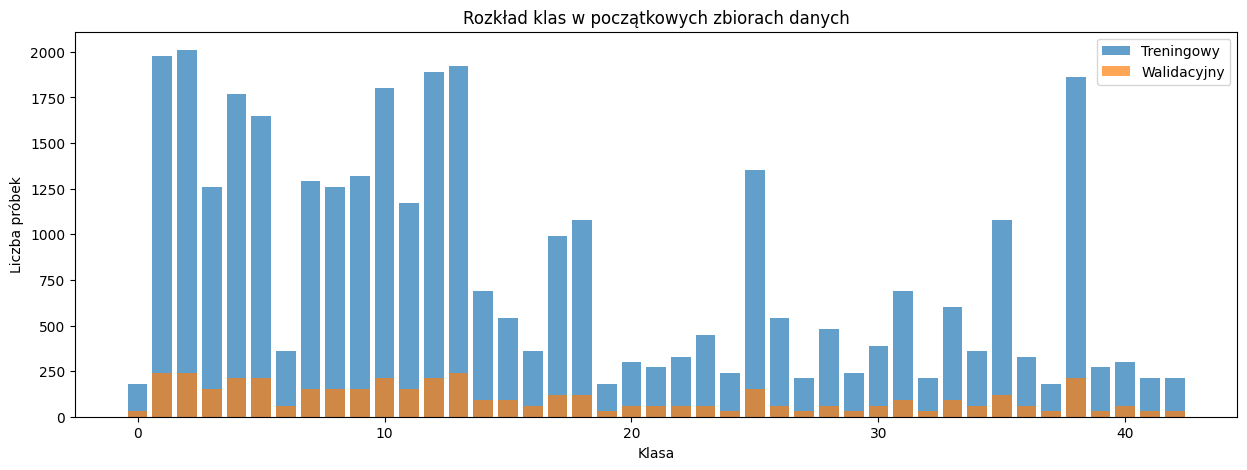

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(old_train, old_counts_train, alpha=0.7, label='Treningowy')
plt.bar(old_val, old_counts_val, alpha=0.7, label='Walidacyjny')
plt.title("Rozkład klas w początkowych zbiorach danych")
plt.xlabel("Klasa")
plt.ylabel("Liczba próbek")
plt.legend()
plt.show()

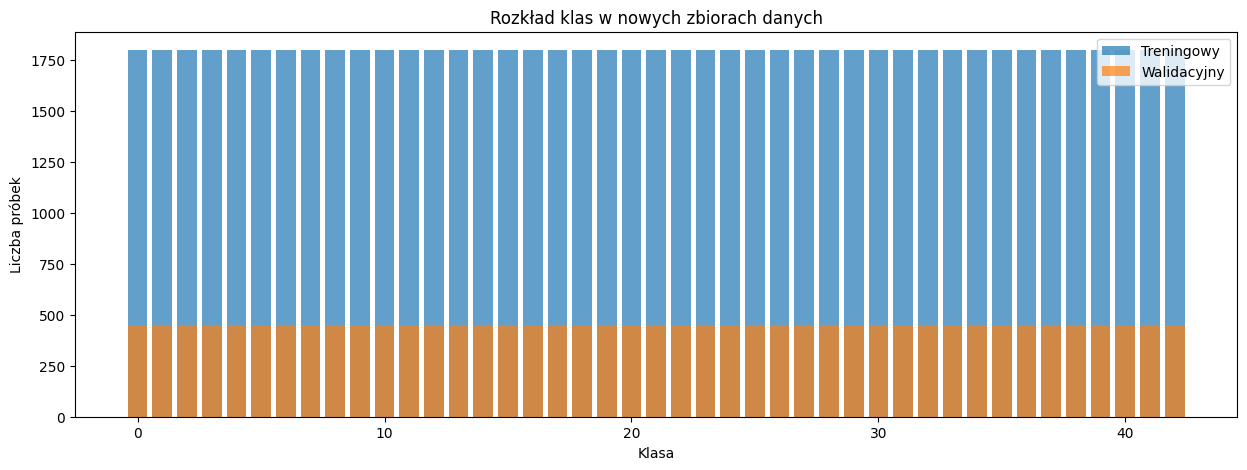

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(unique_train, counts_train, alpha=0.7, label='Treningowy')
plt.bar(unique_val, counts_val, alpha=0.7, label='Walidacyjny')
plt.title("Rozkład klas w nowych zbiorach danych")
plt.xlabel("Klasa")
plt.ylabel("Liczba próbek")
plt.legend()
plt.show()

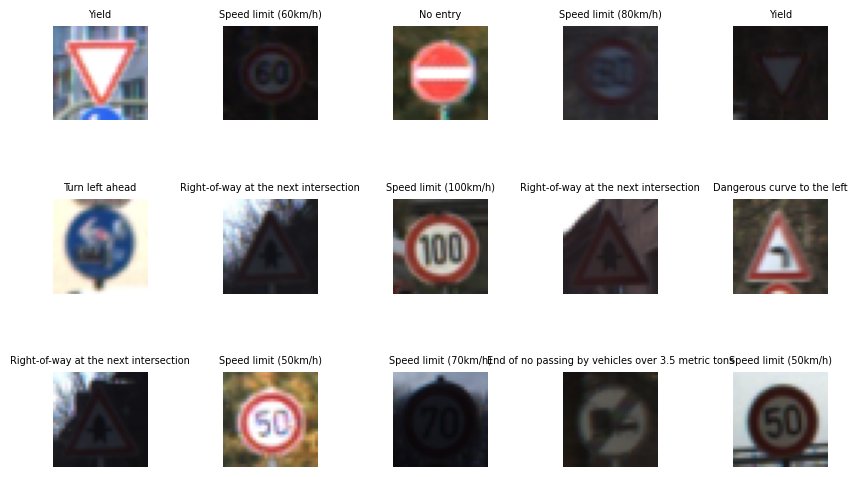

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, axes = plt.subplots(3, 5, figsize=(10, 6))
random_indices = np.random.randint(0, len(X_train), size=15)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]])
    ax.set_title(f"{label_dict[y_train[random_indices[i]]]}", fontsize=7)
    ax.axis("off")
plt.subplots_adjust(hspace=0.5, wspace=0.8)
plt.show()


Przygotowanie danych do uczenia maszynowego

In [ ]:
X_train_normalized=X_train_final/255.0
X_val_normalized=X_val_final/255.0
X_test_normalized=X_test/255.0

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_OHE=to_categorical(y_train_final, num_classes=43)
y_val_OHE=to_categorical(y_val_final, num_classes=43)
y_test_OHE=to_categorical(y_test, num_classes=43)

In [ ]:
def save_data(path, X, y):
    data = {
        'features': X,
        'labels': y
    }
    with open(path, 'wb') as f:
        pickle.dump(data, f)

save_data(data_path + "train_preprocessed.pickle", X_train_normalized, y_train_OHE)
save_data(data_path + "val_preprocessed.pickle", X_val_normalized, y_val_OHE)
save_data(data_path + "test_preprocessed.pickle", X_test_normalized, y_test_OHE)

print("\nPrzygotowane dane zostały zapisane w plikach:")
print("- train_preprocessed.pickle")
print("- val_preprocessed.pickle")
print("- test_preprocessed.pickle")
print("- label_names.csv")


Przygotowane dane zostały zapisane w plikach:
- train_preprocessed.pickle
- val_preprocessed.pickle
- test_preprocessed.pickle
- label_names.csv


In [ ]:
import pickle

data_path = "/content/drive/MyDrive/Traffic_Signs/"

with open(data_path + "train_preprocessed.pickle", 'rb') as f:
    train_data = pickle.load(f)
with open(data_path + "val_preprocessed.pickle", 'rb') as f:
    val_data = pickle.load(f)
with open(data_path + "test_preprocessed.pickle", 'rb') as f:
    test_data = pickle.load(f)

X_train = train_data["features"]
y_train = train_data["labels"]

X_val = val_data["features"]
y_val = val_data["labels"]

X_test = test_data["features"]
y_test = test_data["labels"]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(43, activation='softmax')
])


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_path = "/content/drive/MyDrive/Traffic_Signs/best_model.keras"

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint]
)


Epoch 1/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3278 - loss: 2.4122
Epoch 1: val_loss improved from inf to 0.70887, saving model to best_model.keras
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.3278 - loss: 2.4119 - val_accuracy: 0.8070 - val_loss: 0.7089
Epoch 2/100
2415/2419 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7296 - loss: 0.9008
Epoch 2: val_loss improved from 0.70887 to 0.51768, saving model to best_model.keras
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.7296 - loss: 0.9007 - val_accuracy: 0.8545 - val_loss: 0.5177
Epoch 3/100
2406/2419 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - loss: 0.6729
Epoch 3: val_loss improved from 0.51768 to 0.43586, saving model to best_model.keras
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7961 - loss: 0.6728 - val_accuracy: 0.8704 - val_loss: 0.4359
Epoch 4/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8210 - loss: 0.5847
Epoch 4: val_loss improved from 0

Zapis historii trenowania do pliku CSV

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history.csv', index=False)

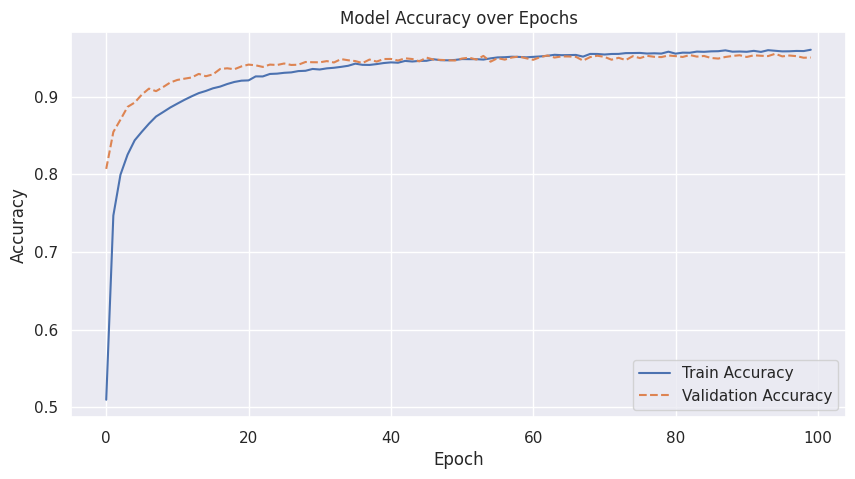

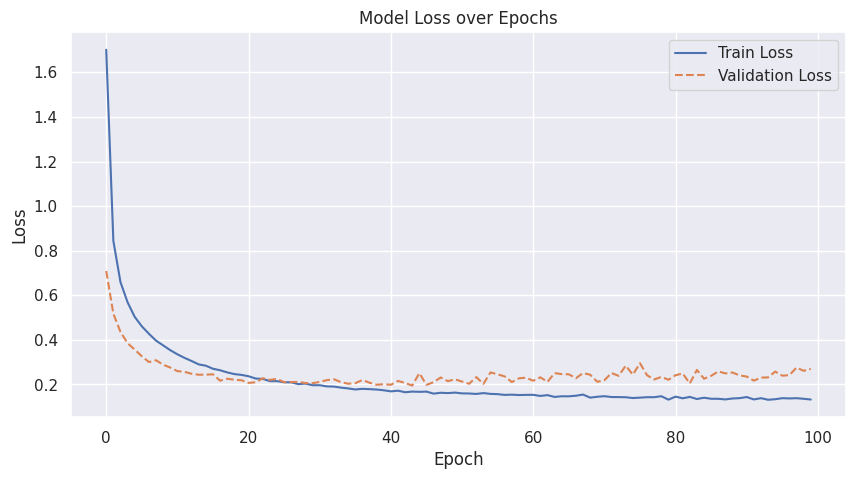

In [ ]:
# Wykres Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Traffic_Signs/accuracy_plot.png')
plt.show()

# Wykres Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Traffic_Signs/loss_plot.png')
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Dokładność na zbiorze testowym: {test_acc * 100:.2f}%")

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9545 - loss: 0.5688
Dokładność na zbiorze testowym: 95.39%


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=label_dict.values()))

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
                                                    precision    recall  f1-score   support

                              Speed limit (20km/h)       0.95      0.93      0.94        60
                              Speed limit (30km/h)       0.97      0.97      0.97       720
                              Speed limit (50km/h)       0.99      0.96      0.97       750
                              Speed limit (60km/h)       0.95      0.94      0.94       450
                              Speed limit (70km/h)       0.98      0.95      0.96       660
                              Speed limit (80km/h)       0.90      0.97      0.93       630
                       End of speed limit (80km/h)       0.97      0.93      0.95       150
                             Speed limit (100km/h)       0.96      0.91      0.93       450
                             Speed limit (120km/h)       0.92      0.96      0.94       450
                                      

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94        60
           1       0.96      0.97      0.97       720
           2       0.97      0.97      0.97       750
           3       0.93      0.92      0.92       450
           4       0.98      0.95      0.97       660
           5       0.90      0.93      0.92       630
           6       0.99      0.95      0.97       150
           7       0.95      0.91      0.93       450
           8       0.94      0.95      0.94       450
           9       0.98      0.99      0.99       480
          10       1.00      0.98      0.99       660
          11       0.90      0.99      0.94       420
          12       1.00      0.96      0.98       690
          13       0.99      0.99      0.99       720
          14       1.00      1.00      1.00       270
          15       0.92      1.00      0.96       210
          16      

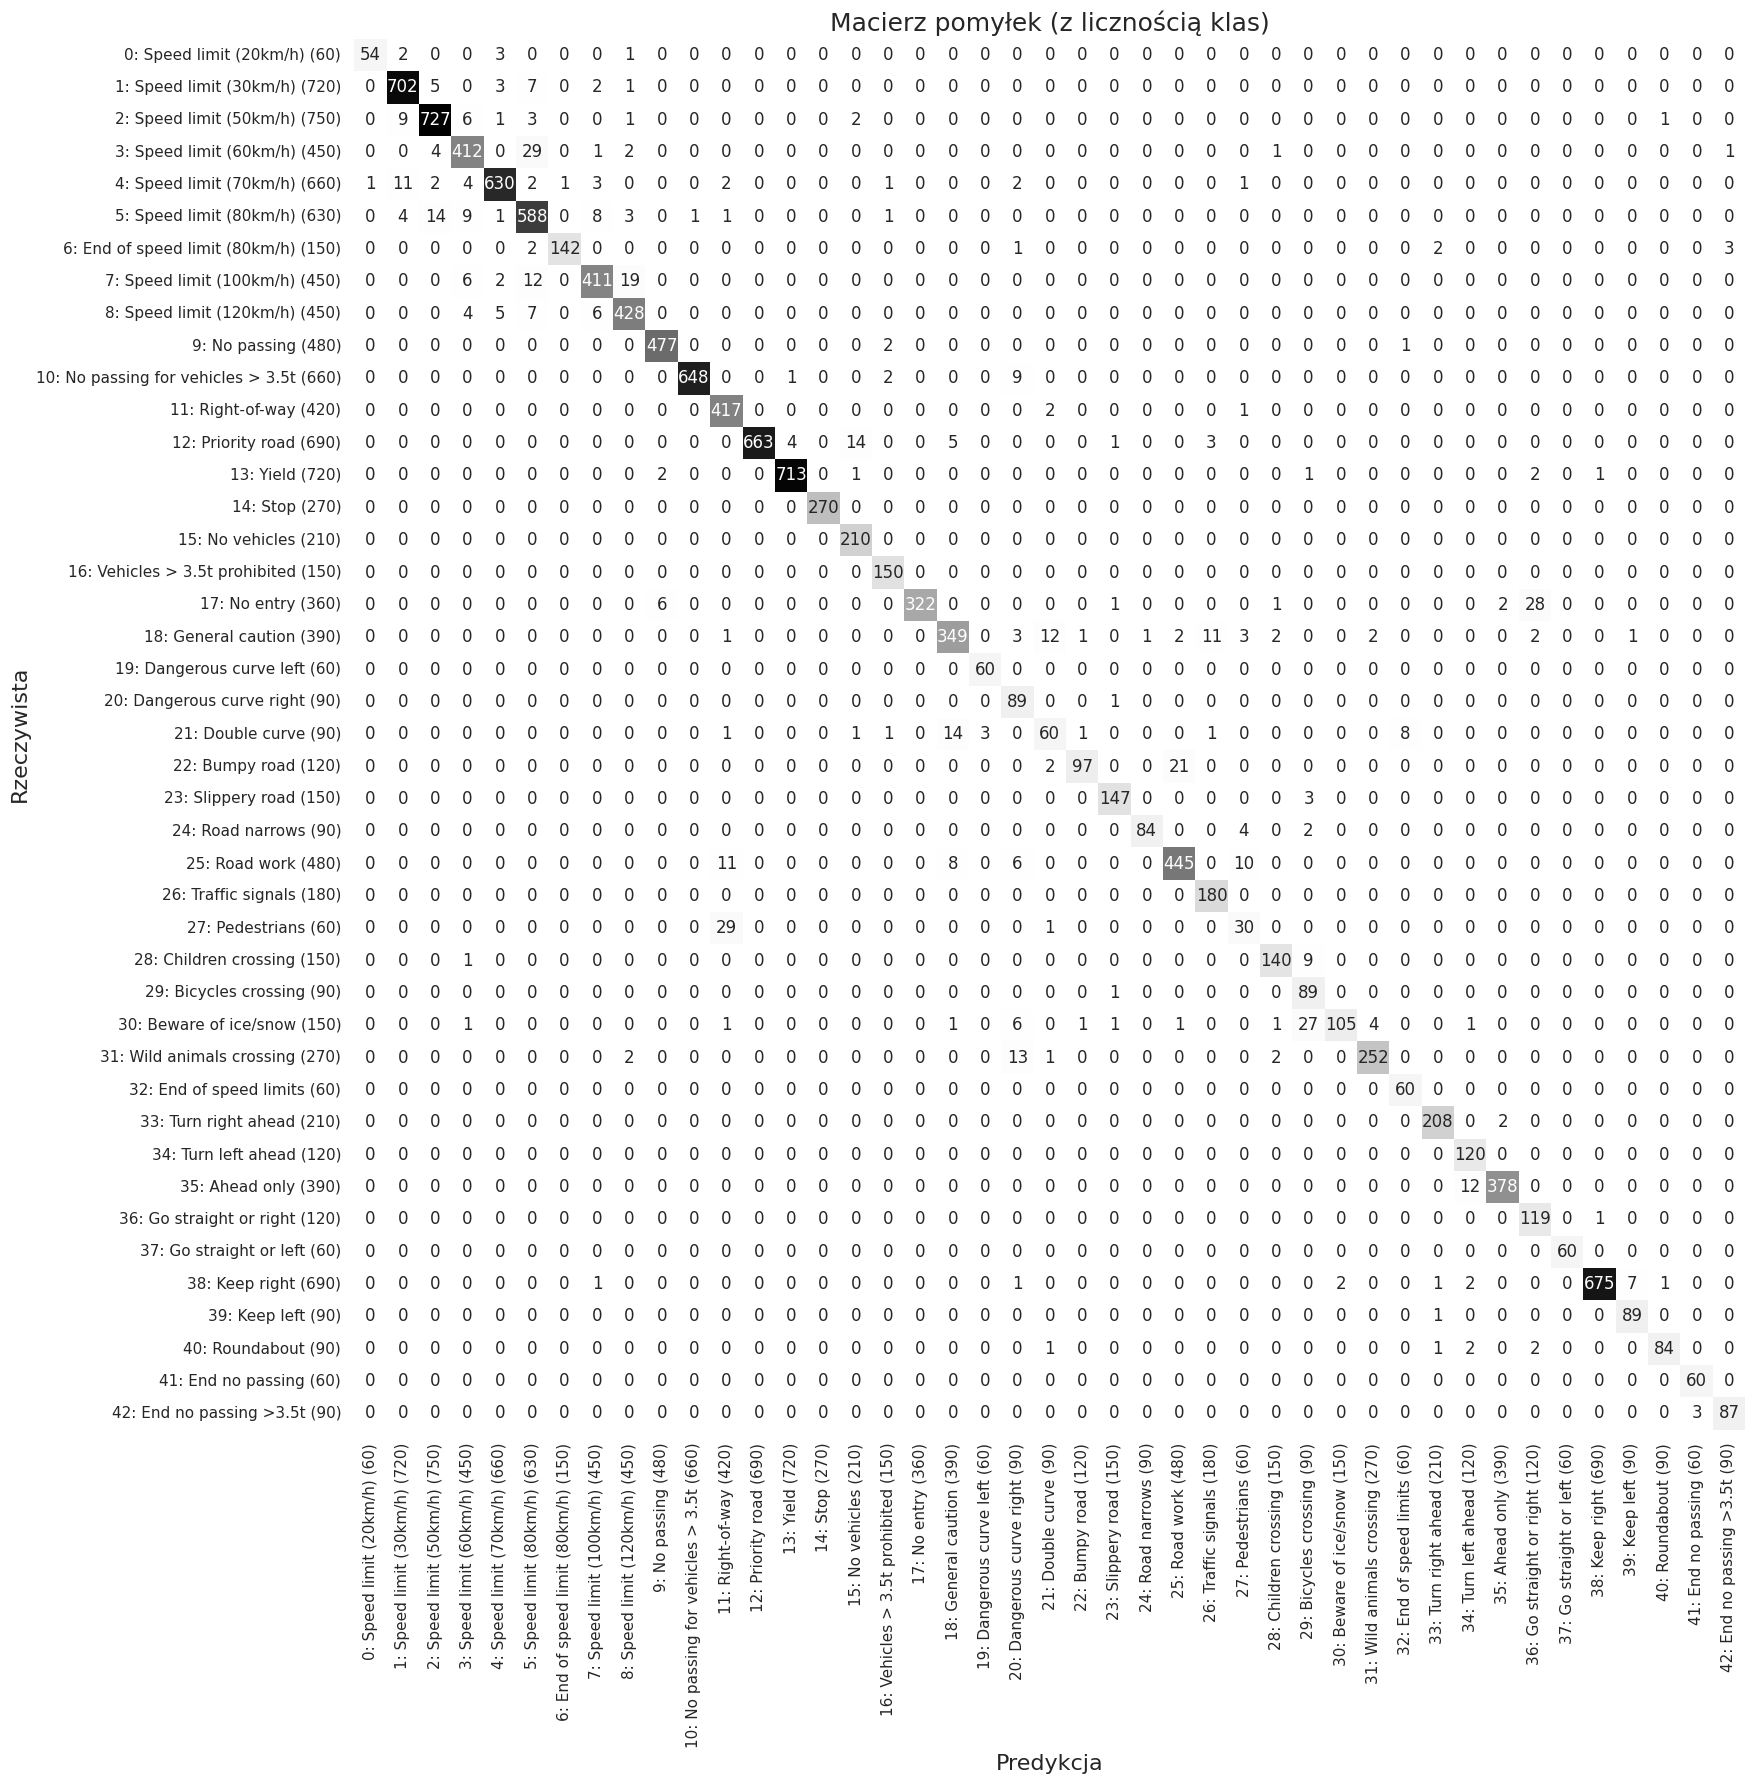

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from keras.models import load_model

# Wczytanie najlepszego modelu
best_model = load_model("best_model.keras")

# Predykcje na danych testowych
y_pred = best_model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1) if y_pred.shape[1] > 1 else (y_pred > 0.5).astype("int32").flatten()

# Zamiana y_test z one-hot na etykiety, jeśli potrzeba
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test

# Raport klasyfikacji
print("Raport klasyfikacji:\n", classification_report(y_test_labels, y_pred_classes))

# Zakładamy, że masz listę etykiet:
labels = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)", "Speed limit (60km/h)",
    "Speed limit (70km/h)", "Speed limit (80km/h)", "End of speed limit (80km/h)", "Speed limit (100km/h)",
    "Speed limit (120km/h)", "No passing", "No passing for vehicles > 3.5t", "Right-of-way", "Priority road",
    "Yield", "Stop", "No vehicles", "Vehicles > 3.5t prohibited", "No entry", "General caution",
    "Dangerous curve left", "Dangerous curve right", "Double curve", "Bumpy road", "Slippery road",
    "Road narrows", "Road work", "Traffic signals", "Pedestrians", "Children crossing", "Bicycles crossing",
    "Beware of ice/snow", "Wild animals crossing", "End of speed limits", "Turn right ahead",
    "Turn left ahead", "Ahead only", "Go straight or right", "Go straight or left", "Keep right", "Keep left",
    "Roundabout", "End no passing", "End no passing >3.5t"
]

# Liczność klas w zbiorze testowym
import numpy as np
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test

class_counts = np.bincount(y_test_labels)
labels_with_counts = [f"{i}: {label} ({class_counts[i]})" for i, label in enumerate(labels)]

cm = confusion_matrix(y_test_labels, y_pred_classes)

# Macierz pomyłek z adnotacjami liczbowymi
plt.figure(figsize=(22, 18))
sns.set(font_scale=1.0)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", cbar=False, square=True,
            xticklabels=labels_with_counts,
            yticklabels=labels_with_counts)
plt.title("Macierz pomyłek (z licznością klas)", fontsize=18)
plt.xlabel("Predykcja", fontsize=16)
plt.ylabel("Rzeczywista", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Traffic_Signs/confusion_matrix_with_counts.png")
plt.show()



#Optymalizacja

In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 8.8 MB/s eta 0:00:00


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from keras.optimizers import Adam, RMSprop
from keras_tuner.tuners import RandomSearch
from keras.callbacks import EarlyStopping
from keras import Input
from keras_tuner.tuners import Hyperband

# Liczba klas
num_classes = y_train.shape[1]

def build_model(hp):
    model = Sequential()

    model.add(Input(shape=(32, 32, 3)))
    model.add(Conv2D(hp.Int('conv1_filters', 32, 64, step=32), (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(hp.Float('dropout1', 0.2, 0.4, step=0.1)))

    model.add(Conv2D(hp.Int('conv2_filters', 64, 128, step=32), (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(hp.Float('dropout2', 0.2, 0.4, step=0.1)))

    model.add(Flatten())
    model.add(Dense(hp.Int('dense_units', 64, 256, step=64), activation='relu'))
    model.add(Dropout(hp.Float('dropout3', 0.2, 0.4, step=0.1)))

    model.add(Dense(num_classes, activation='softmax'))

    optimizer_choice = hp.Choice('optimizer', ['adam', 'rmsprop'])
    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='log'))
    else:
        optimizer = RMSprop(learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='log'))

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Tuner
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='cnn_random_search'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Przeszukiwanie
tuner.search(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Najlepszy model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Trial 20 Complete [00h 05m 00s]
val_accuracy: 0.8364858031272888

Best val_accuracy So Far: 0.966511607170105
Total elapsed time: 02h 13m 49s


In [ ]:
optimized_model = tuner.hypermodel.build(best_hps)

history_opt = optimized_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[ModelCheckpoint("best_optimized_model.keras", monitor="val_loss", save_best_only=True)]
)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

Epoch 1/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.3712 - loss: 2.3512 - val_accuracy: 0.8384 - val_loss: 0.5732
Epoch 2/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8065 - loss: 0.6625 - val_accuracy: 0.8875 - val_loss: 0.3887
Epoch 3/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8617 - loss: 0.4691 - val_accuracy: 0.9012 - val_loss: 0.3430
Epoch 4/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8823 - loss: 0.3842 - val_accuracy: 0.9152 - val_loss: 0.2862
Epoch 5/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8985 - loss: 0.3283 - val_accuracy: 0.9184 - val_loss: 0.2709
Epoch 6/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9083 - loss: 0.2913 - val_accuracy: 0.9279 - val_loss: 0.2459
Epoch 7/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9161 - loss: 0.2665 - val_accuracy: 0.9339 - val_loss: 0.2310
Epoch 8/100
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9264 -

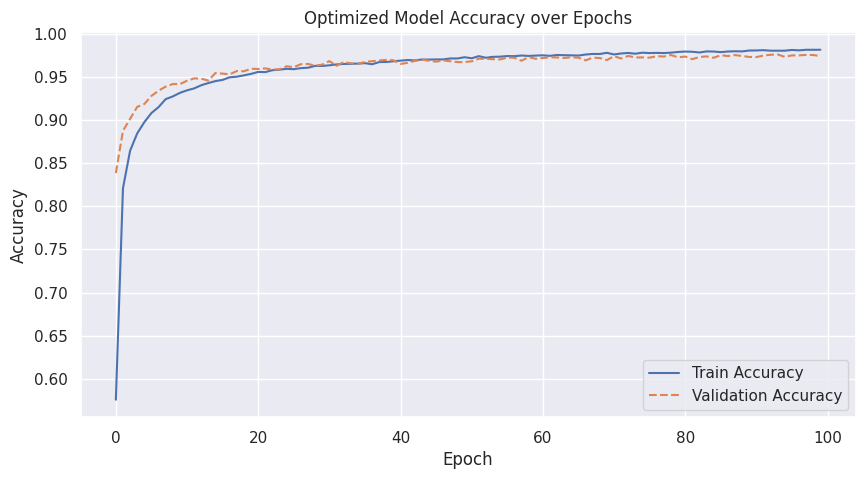

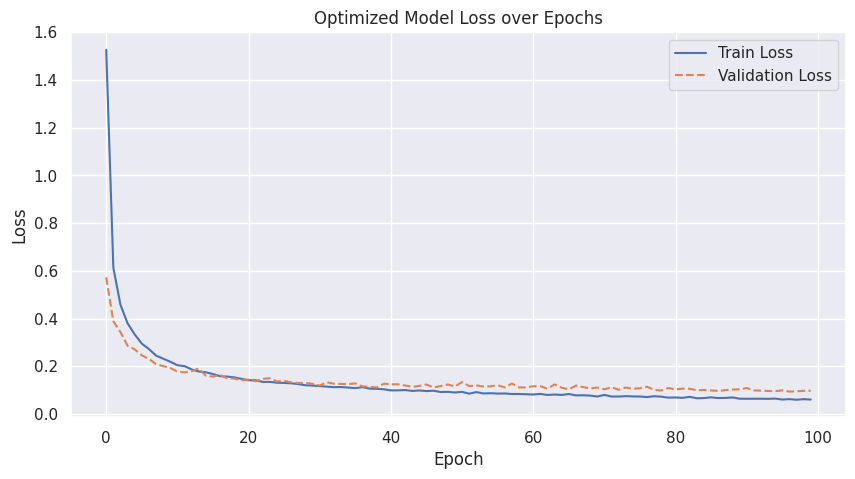

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_opt.history['accuracy'], label='Train Accuracy')
plt.plot(history_opt.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
plt.title('Optimized Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Traffic_Signs/optimized_accuracy_plot.png')
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(history_opt.history['loss'], label='Train Loss')
plt.plot(history_opt.history['val_loss'], label='Validation Loss', linestyle='dashed')
plt.title('Optimized Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Traffic_Signs/optimized_loss_plot.png')
plt.show()

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        60
           1       0.96      0.98      0.97       720
           2       0.98      0.97      0.98       750
           3       0.95      0.97      0.96       450
           4       0.99      0.96      0.97       660
           5       0.97      0.94      0.95       630
           6       0.93      0.76      0.84       150
           7       0.95      0.88      0.91       450
           8       0.87      0.99      0.93       450
           9       0.96      0.99      0.97       480
          10       0.99      0.98      0.99       660
          11       0.97      1.00      0.98       420
          12       1.00      0.93      0.97       690
          13       0.99      1.00      0.99       720
          14       0.97      1.00      0.99       270
          15       0.99      0.99      0.99       210
          16      

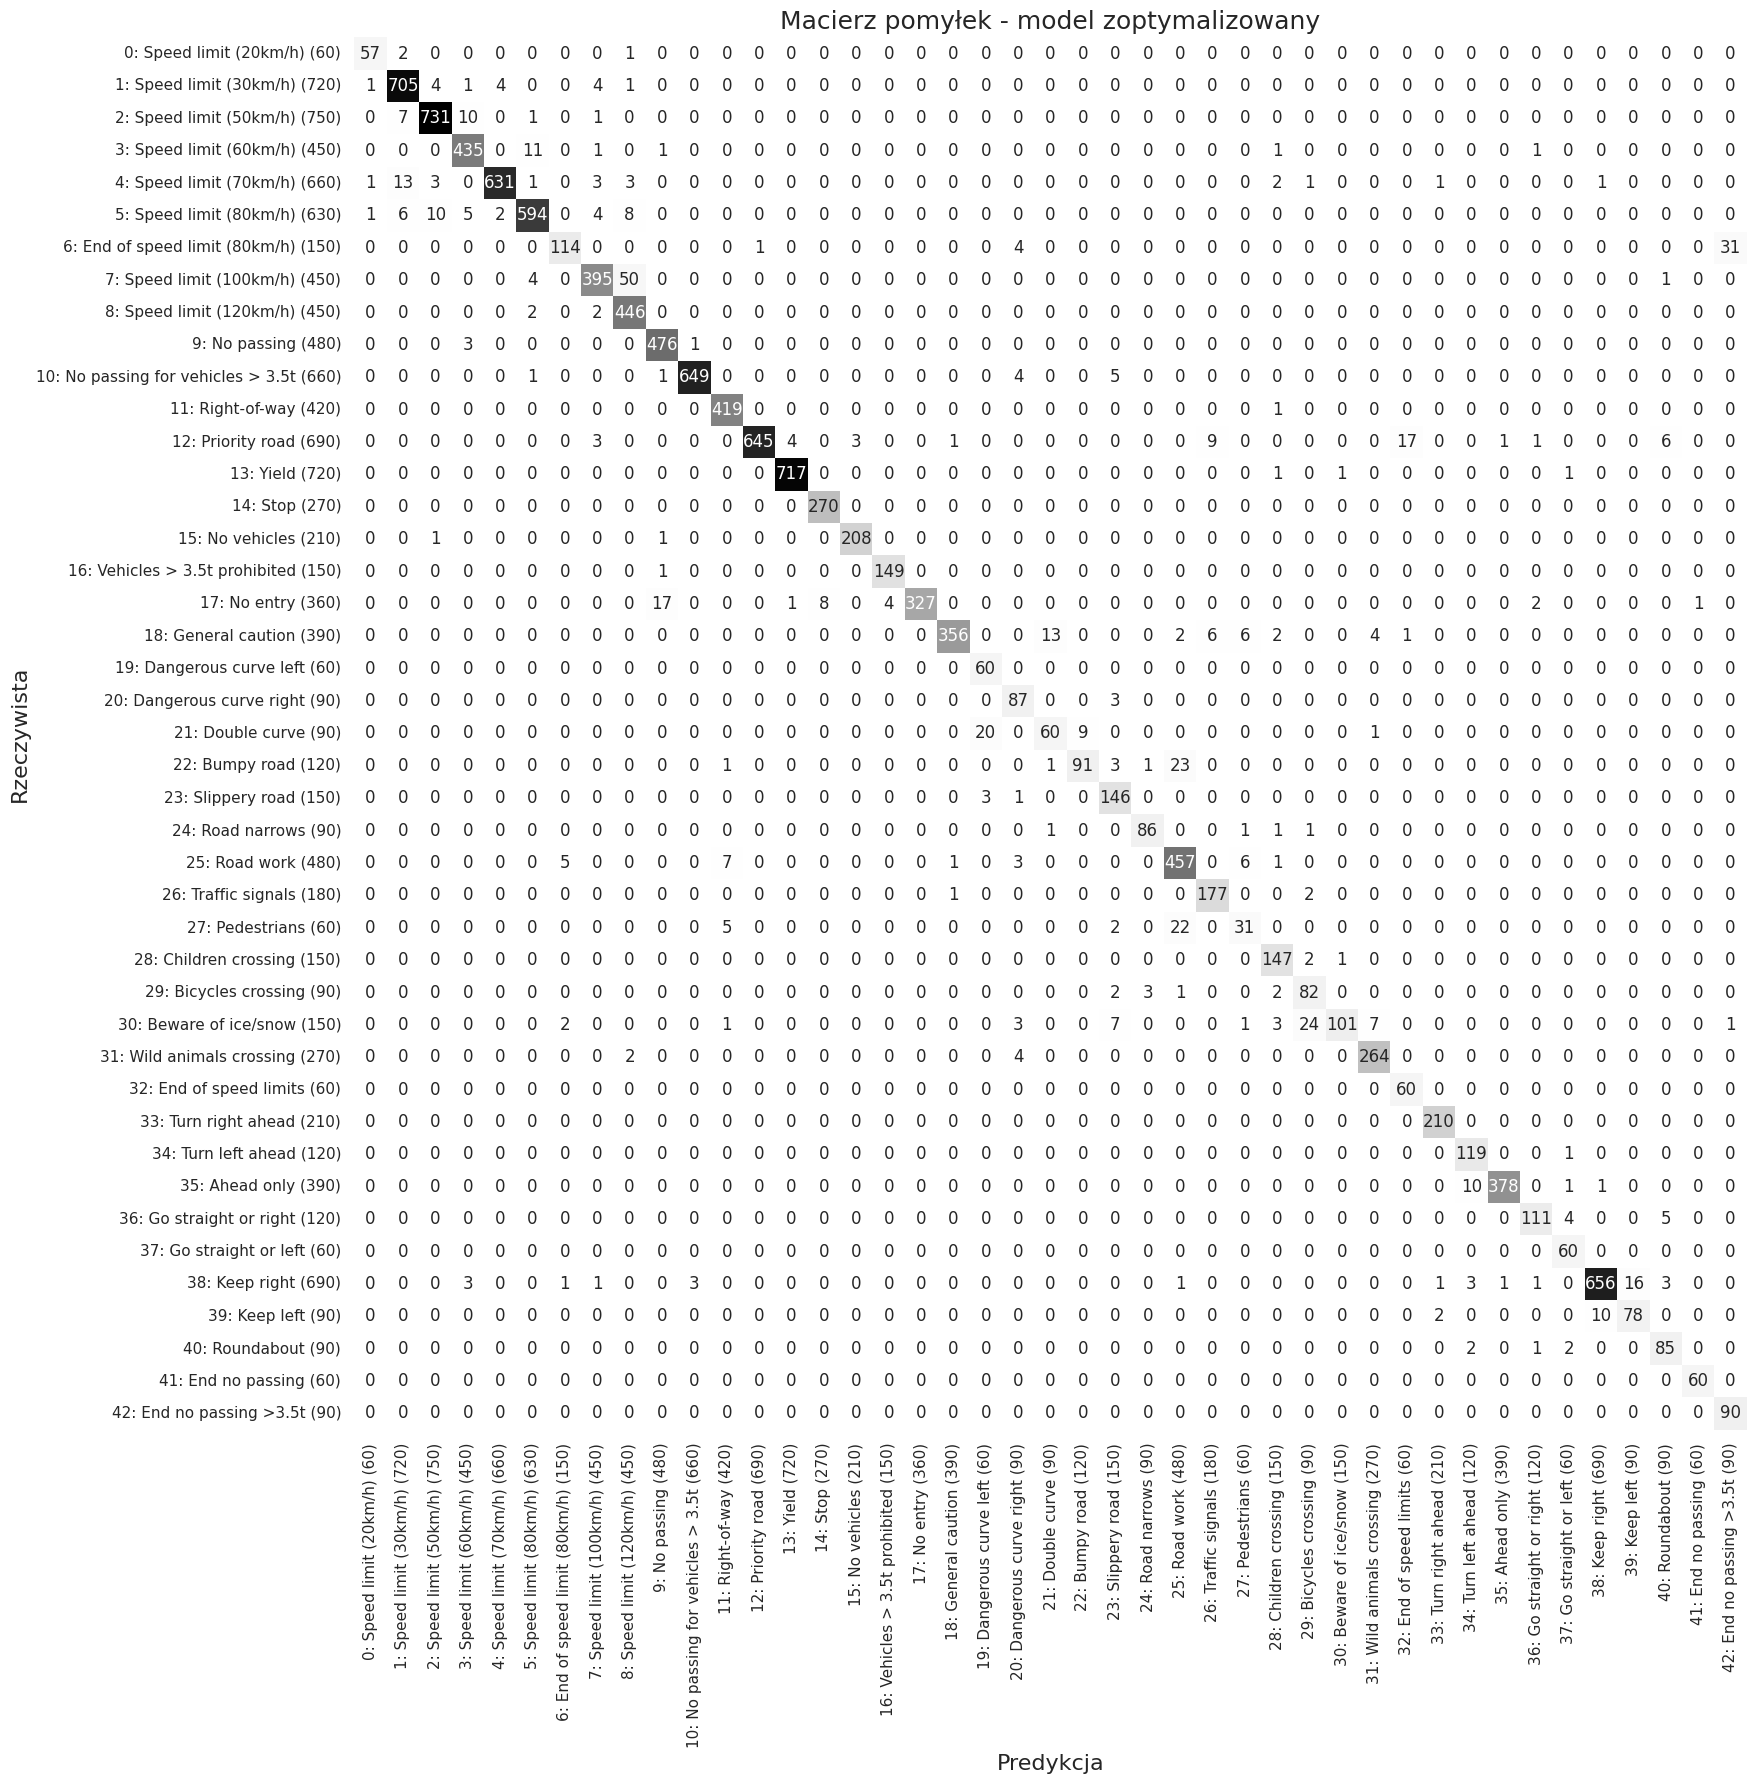

In [ ]:
# Predykcja zoptymalizowanym modelem
y_pred = optimized_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Konwersja y_test do etykiet (jeśli one-hot)
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# Raport klasyfikacji
print("Raport klasyfikacji:\n", classification_report(y_true, y_pred_classes))

# Lista etykiet klas
labels = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)", "Speed limit (60km/h)",
    "Speed limit (70km/h)", "Speed limit (80km/h)", "End of speed limit (80km/h)", "Speed limit (100km/h)",
    "Speed limit (120km/h)", "No passing", "No passing for vehicles > 3.5t", "Right-of-way", "Priority road",
    "Yield", "Stop", "No vehicles", "Vehicles > 3.5t prohibited", "No entry", "General caution",
    "Dangerous curve left", "Dangerous curve right", "Double curve", "Bumpy road", "Slippery road",
    "Road narrows", "Road work", "Traffic signals", "Pedestrians", "Children crossing", "Bicycles crossing",
    "Beware of ice/snow", "Wild animals crossing", "End of speed limits", "Turn right ahead",
    "Turn left ahead", "Ahead only", "Go straight or right", "Go straight or left", "Keep right", "Keep left",
    "Roundabout", "End no passing", "End no passing >3.5t"
]

# Liczność klas
class_counts = np.bincount(y_true)
labels_with_counts = [f"{i}: {label} ({class_counts[i]})" for i, label in enumerate(labels)]

# Macierz pomyłek
cm = confusion_matrix(y_true, y_pred_classes)

# Wykres
plt.figure(figsize=(22, 18))
sns.set(font_scale=1.0)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", cbar=False, square=True,
            xticklabels=labels_with_counts,
            yticklabels=labels_with_counts)
plt.title("Macierz pomyłek - model zoptymalizowany", fontsize=18)
plt.xlabel("Predykcja", fontsize=16)
plt.ylabel("Rzeczywista", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Traffic_Signs/confusion_matrix_with_counts_optimized.png")
plt.show()